# Hotel booking
---

### Segmentation question (RQ1)

**What recurring booking-behaviour profiles emerge from hotel reservation
records, using only information available at the moment of booking
confirmation?**

- Unit of analysis: one row = one booking record.
- Conclusions are framed as recurring booking behaviours, not as
  definitive customer types: the dataset has no stable guest identifier
  and a single guest may produce bookings that fall into different
  profiles depending on the trip context.
- Index time = booking confirmation. Every clustering input must be
  available at or before that point. Anything updated, accrued, or
  determined afterwards (e.g. assigned room, booking changes, days on
  the waiting list, cancellation outcome) is reserved for post-hoc
  profiling.


In [19]:
import hashlib
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [20]:
FAST_MODE  = False
FAST_N     = 5_000
FAST_SEED  = 42

SEEDS    = [0, 1, 2, 3, 4]   # fixed seeds for all experiments

PROJECT_ROOT = Path('..').resolve()
DATA_CSV     = PROJECT_ROOT / 'data' / 'raw' / 'hotel_bookings_course_release_v1.csv'
FIGURES_DIR  = PROJECT_ROOT / 'figures'
TABLES_DIR   = PROJECT_ROOT / 'tables'
EXP_CSV      = PROJECT_ROOT / 'experiments.csv'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print('Project root :', PROJECT_ROOT)
print('Data file    :', DATA_CSV)
print('Data exists  :', DATA_CSV.exists())
print('Fast mode    :', FAST_MODE)

Project root : C:\Projects\ANSup\ANSup-hotel-project
Data file    : C:\Projects\ANSup\ANSup-hotel-project\data\raw\hotel_bookings_course_release_v1.csv
Data exists  : True
Fast mode    : False


---
## 1. Data loading and integrity check

In [21]:
def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            h.update(chunk)
    return h.hexdigest()

EXPECTED_SHA256 = '7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06'

actual = sha256(DATA_CSV)
assert actual == EXPECTED_SHA256, (
    f'Checksum mismatch!\n  expected: {EXPECTED_SHA256}\n  got: {actual}'
)
print('SHA-256 OK:', actual)

SHA-256 OK: 7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06


In [22]:
df_raw = pd.read_csv(DATA_CSV)
print('Shape:', df_raw.shape)
print('\nDtype counts:')
print(df_raw.dtypes.value_counts())
df_raw.head(3)

Shape: (119390, 32)

Dtype counts:
int64      16
str        12
float64     4
Name: count, dtype: int64


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02


In [23]:
if FAST_MODE:
    df = df_raw.sample(n=FAST_N, random_state=FAST_SEED).reset_index(drop=True)
    print(f'[FAST MODE] Subsampled to {len(df)} rows (seed={FAST_SEED})')
else:
    df = df_raw.copy()
    print(f'[FULL MODE] Using all {len(df)} rows')

[FULL MODE] Using all 119390 rows


---
## 2. Exploratory data analysis

### 2.1 Missingness

In [24]:
missing = (
    df.isnull().sum()
    .rename('n_missing')
    .to_frame()
    .assign(pct=lambda x: (x['n_missing'] / len(df) * 100).round(2))
    .query('n_missing > 0')
    .sort_values('pct', ascending=False)
)
print('Columns with missing values:')
display(missing)

Columns with missing values:


,n_missing,pct
company,112593,94.3100
agent,16340,13.6900
country,488,0.4100
children,4,0.0000


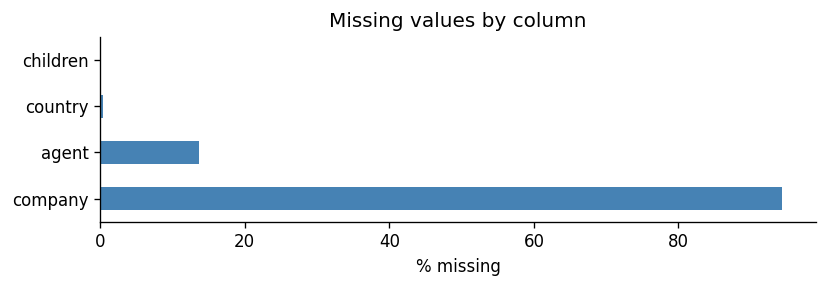

In [25]:
if not missing.empty:
    fig, ax = plt.subplots(figsize=(7, 2.5))
    missing['pct'].plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel('% missing')
    ax.set_title('Missing values by column')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'eda_missing.png')
    plt.show()

**Missingness takeaways:**  
`company` and `agent` have high emptiness and carry no real behavioural signal, since they're internal IDs, we exclude them. `country` is almost complete, a simple `'Unknown'` fill before grouping is sufficient.

### 2.2 Outliers (IQR method)

In [26]:
def iqr_outlier_report(df, cols):
    rows = []
    for c in cols:
        q1, q3 = df[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((df[c] < lo) | (df[c] > hi)).sum()
        rows.append({
            'column': c, 'q1': q1, 'q3': q3,
            'lower_fence': lo, 'upper_fence': hi,
            'n_outliers': n_out,
            'pct_outliers': round(n_out / len(df) * 100, 2)
        })
    return pd.DataFrame(rows).sort_values('pct_outliers', ascending=False)

num_cols_raw = df.select_dtypes(include='number').columns.tolist()
outlier_report = iqr_outlier_report(df, num_cols_raw)
display(outlier_report)

,column,q1,q3,lower_fence,upper_fence,n_outliers,pct_outliers
7,adults,2.0000,2.0000,2.0000,2.0000,29710,24.8800
13,booking_changes,0.0000,0.0000,0.0000,0.0000,18076,15.1400
8,children,0.0000,0.0000,0.0000,0.0000,8590,7.1900
18,required_car_parking_spaces,0.0000,0.0000,0.0000,0.0000,7416,6.2100
11,previous_cancellations,0.0000,0.0000,0.0000,0.0000,6484,5.4300
10,is_repeated_guest,0.0000,0.0000,0.0000,0.0000,3810,3.1900
17,adr,69.2900,126.0000,-15.7750,211.0650,3793,3.1800
16,days_in_waiting_list,0.0000,0.0000,0.0000,0.0000,3698,3.1000
12,previous_bookings_not_canceled,0.0000,0.0000,0.0000,0.0000,3620,3.0300
6,stays_in_week_nights,1.0000,3.0000,-2.0000,6.0000,3354,2.8100


**Outlier takeaways:**  
Most "outliers" here are artefacts of sparse, heavily-skewed integer columns where IQR = 0: `adults` , `booking_changes`, `children` etc. These are deviations from a dominant mode. The only column with genuine extremes is `adr` (high-rate bookings). Since we're using `StandardScaler`, outliers get compressed rather than removed, so no clipping needed at this stage.

### 2.3 Numerical distributions

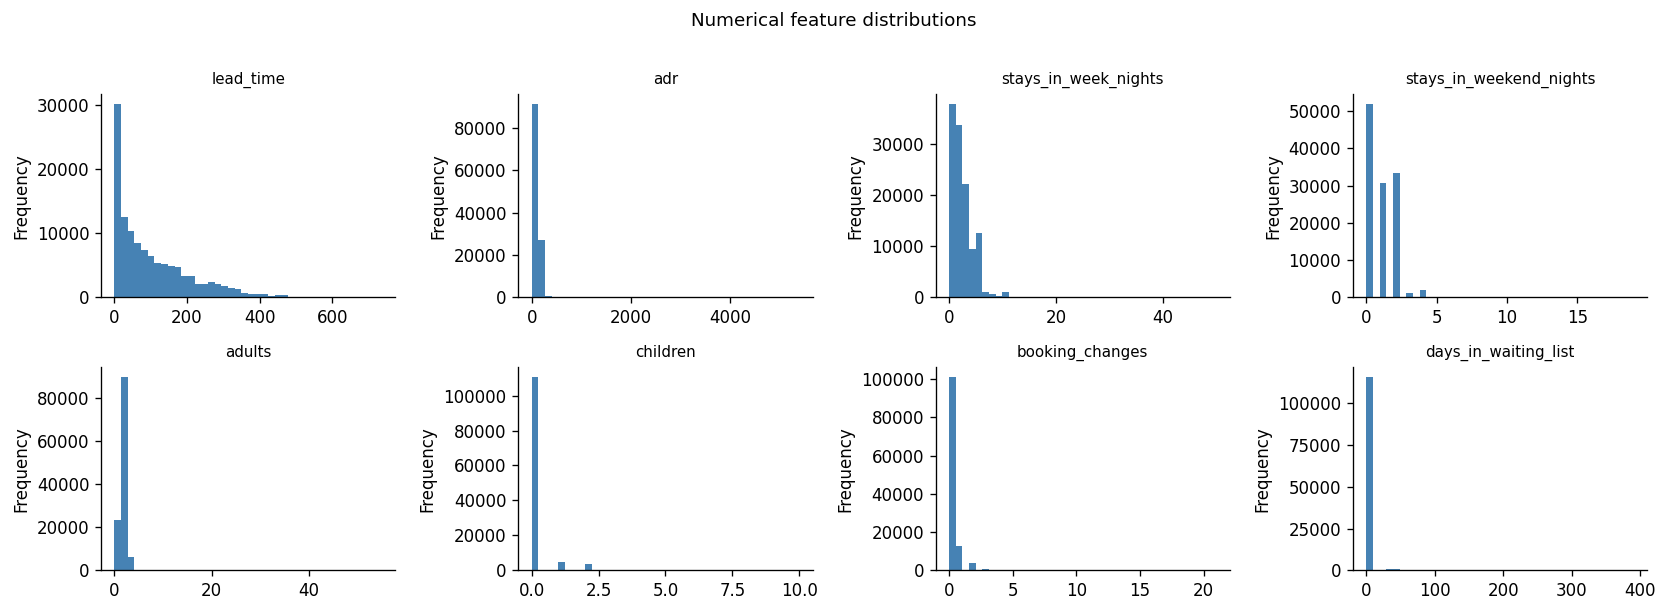

In [27]:
plot_num = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
            'adults', 'children', 'booking_changes', 'days_in_waiting_list']

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for ax, col in zip(axes.flat, plot_num):
    df[col].dropna().plot.hist(bins=40, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Numerical feature distributions', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_numerical_distributions.png', bbox_inches='tight')
plt.show()

**Distribution takeaways:**  
Most numerical features are near-zero concentrated. `lead_time` and `adr` have long tails, most bookings are last-minute and mid-range, but there's a meaningful tail of far-in-advance, high-spend bookings. `stays_in_week_nights` peaks at 2–3 nights. `children`, `babies`, `booking_changes`, and `days_in_waiting_list` are all dominated by zero. These distributions motivate standardisation over min-max scaling

### 2.4 Categorical features

In [28]:
cat_cols_raw = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns and cardinality:')
for c in cat_cols_raw:
    print(f'  {c:45s} {df[c].nunique():4d} unique')

Categorical columns and cardinality:
  hotel                                            2 unique
  arrival_date_month                              12 unique
  meal                                             5 unique
  country                                        177 unique
  market_segment                                   8 unique
  distribution_channel                             5 unique
  reserved_room_type                              10 unique
  assigned_room_type                              12 unique
  deposit_type                                     3 unique
  customer_type                                    4 unique
  reservation_status                               3 unique
  reservation_status_date                        926 unique


In [29]:
country_counts = df['country'].value_counts()
for n in [5, 10, 15, 20]:
    cov = country_counts.head(n).sum() / country_counts.sum() * 100
    print(f'  Top {n:2d} countries -> {cov:.1f}% of bookings')

  Top  5 countries -> 73.2% of bookings
  Top 10 countries -> 84.8% of bookings
  Top 15 countries -> 91.0% of bookings
  Top 20 countries -> 94.2% of bookings


**Country grouping takeaways:**  
The top 15 countries already cover 91% of bookings. Beyond that, coverage gains diminish quickly. We'll keep the top 15 explicitly and collapse the rest into `'Other'`, keeping dimensionality manageable without losing meaningful geographic signal.

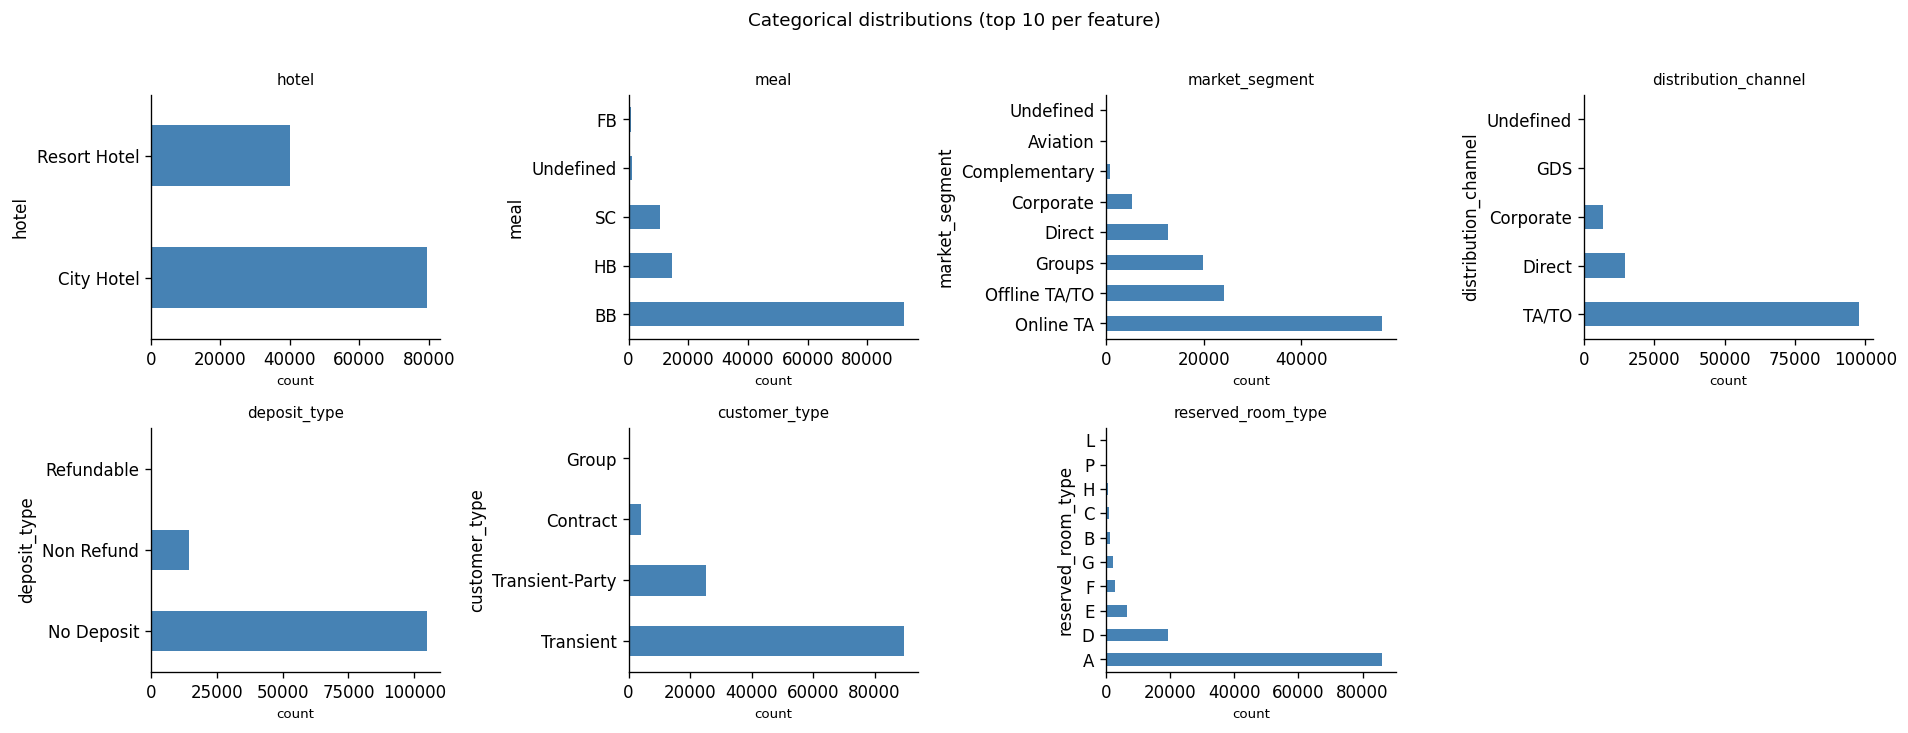

In [30]:
plot_cats = ['hotel', 'meal', 'market_segment', 'distribution_channel',
             'deposit_type', 'customer_type', 'reserved_room_type']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, plot_cats):
    df[col].value_counts().head(10).plot.barh(ax=ax, color='steelblue')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('count', fontsize=8)
axes.flat[-1].set_visible(False)
plt.suptitle('Categorical distributions (top 10 per feature)', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_categorical_distributions.png', bbox_inches='tight')
plt.show()

**Categorical distributions takeaways:**  
Several features are heavily concentrated in a single category. `deposit_type` is almost entirely "No Deposit", which makes it a near-constant and therefore weak discriminator. `meal` is dominated by BB, `customer_type` by Transient, and `reserved_room_type` by type A. `market_segment` shows more spread, with Online TA and Offline TA/TO as the main channels. The practical consequence is that many OHE columns will be near-zero for most observations, contributing little to cluster separation while still adding dimensions to the distance space.

### 2.5 Correlation matrix (numerical)

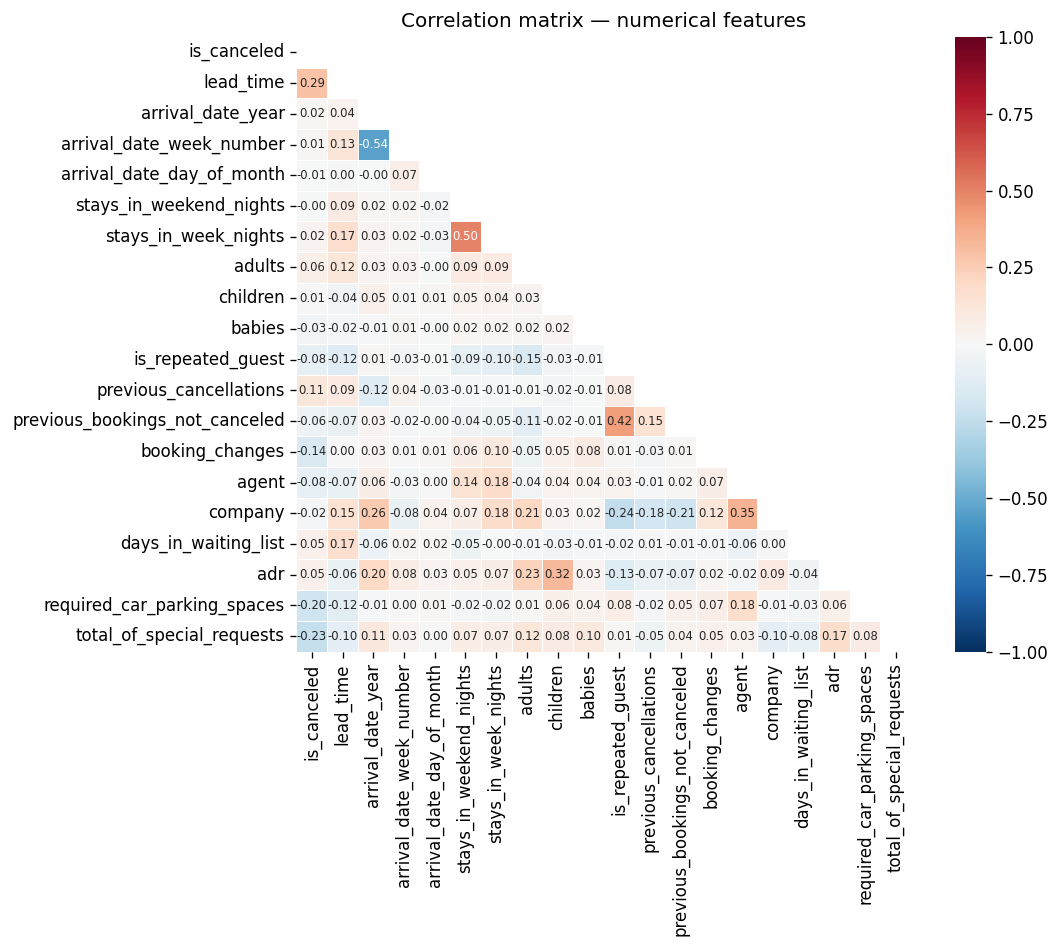

In [31]:
corr = df[num_cols_raw].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, square=True, ax=ax)
ax.set_title('Correlation matrix — numerical features')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_correlation_matrix.png', bbox_inches='tight')
plt.show()

**Correlation takeaways:**  
Multicollinearity is generally low across the features used for clustering. The most notable pairs are:

- `stays_in_weekend_nights` / `stays_in_week_nights`: moderately correlated as expected, but they capture distinct stay patterns (short city break vs longer week trip) so both are kept
- `adr` / `stays_in_week_nights` and `adr` / `adults`: longer stays and larger parties tend to pay more; `adr` carries real signal
- `previous_bookings_not_canceled` / `previous_cancellations`: both reflect guest activity volume rather than reliability, so they are not redundant
- `arrival_date_year` and `arrival_date_week_number`: is explained by the fact that the dataset only covers July 2015 to August 2017, so 2015 has only late year weeks and 2017 only early year weeks, creating an artificial negative association. Since `arrival_date_year` carries no guest behaviour signal, it's a candidate for exclusion.
- `company` / `agent`: strongly correlated but both excluded anyway. `is_canceled` correlations are shown for context only, it's a leakage column and will not enter the clustering pipeline.

---
## 3. Feature governance

Single source of truth: `src/preprocessing/feature_config.py`. Every
column is assigned exactly one role (after the post-feedback revision).

**Leakage exclusions — post-event, unknown at index time**

| Column | Reason |
|--------|--------|
| `is_canceled` | Booking outcome |
| `reservation_status` | Post-arrival operational state |
| `reservation_status_date` | Date of that post-arrival state change |

**Post-confirmation exclusions — only resolved after booking is taken (Rec 1)**

| Column | Reason |
|--------|--------|
| `assigned_room_type` | Set on check-in / operational rebalancing |
| `booking_changes` | Counter accrues only via post-booking modifications |
| `days_in_waiting_list` | Accrues between booking and confirmation/cancellation |

**Identifier exclusions — no behavioural signal**

| Column | Reason |
|--------|--------|
| `agent` | Travel-agent ID; 13.7 % missing |
| `company` | Company ID; 94.3 % missing |

**Profiling-only — kept for post-hoc cluster description, never as input (Rec 2)**

`meal`, `required_car_parking_spaces`, `total_of_special_requests`, `adr`.
ADR is a downstream consequence of the choices we cluster on (room type,
dates, party size, channel); using it as a clustering input would
conflate cluster definition with cluster description.

**Compact seasonality encoding (Rec 3)**

The four raw arrival-date columns (`arrival_date_year`,
`arrival_date_week_number`, `arrival_date_day_of_month`,
`arrival_date_month`) are redundant and destabilise the distance
structure. We replace them with a single cyclic encoding derived from
`arrival_date_month`:

```
arrival_month_sin = sin(2π · month / 12)
arrival_month_cos = cos(2π · month / 12)
```

Compact (two features), behaviourally justified (seasons recur), and
respects calendar topology (December ↔ January are adjacent).

**Country with caution (Rec 6)**

`country` is retained only with rare-category grouping (min frequency =
100). It must be read as **market-of-origin booking behaviour**, never as
nationality, and never as a substantive explanation for cluster
identity. The risk of proxy discrimination is documented up-front and is
reiterated in every cluster narrative.


In [32]:
LEAKAGE_COLS           = ['is_canceled', 'reservation_status', 'reservation_status_date']
POST_CONFIRMATION_COLS = ['assigned_room_type', 'booking_changes', 'days_in_waiting_list']
ID_COLS                = ['agent', 'company']
PROFILING_ONLY         = ['meal', 'required_car_parking_spaces',
                          'total_of_special_requests', 'adr']
RAW_TEMPORAL_COLS      = ['arrival_date_year', 'arrival_date_week_number',
                          'arrival_date_day_of_month', 'arrival_date_month']

DROP_COLS = LEAKAGE_COLS + POST_CONFIRMATION_COLS + ID_COLS

# Compact seasonality encoding (Rec 3)
MONTH_TO_NUM = {m: i + 1 for i, m in enumerate([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December',
])}
month_num = df['arrival_date_month'].map(MONTH_TO_NUM)
df['arrival_month_sin'] = np.sin(2 * np.pi * month_num / 12)
df['arrival_month_cos'] = np.cos(2 * np.pi * month_num / 12)

CLUSTER_NUMERICAL = [
    'lead_time',
    'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies',
    'is_repeated_guest',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'arrival_month_sin', 'arrival_month_cos',
]
CLUSTER_CATEGORICAL = [
    'hotel', 'country', 'market_segment', 'distribution_channel',
    'reserved_room_type', 'deposit_type', 'customer_type',
]

# Profiling frame: kept for post-hoc cluster description, never used as input.
profiling_cols = (PROFILING_ONLY
                  + [c for c in LEAKAGE_COLS if c in df.columns]
                  + RAW_TEMPORAL_COLS)
df_profiling = df[[c for c in profiling_cols if c in df.columns]].copy()

# Clustering input: governance + cyclic seasonality applied.
df_input = df[CLUSTER_NUMERICAL + CLUSTER_CATEGORICAL].copy()

print(f'Clustering numerical   ({len(CLUSTER_NUMERICAL)}): {CLUSTER_NUMERICAL}')
print(f'Clustering categorical ({len(CLUSTER_CATEGORICAL)}): {CLUSTER_CATEGORICAL}')
print(f'Profiling-only         ({df_profiling.shape[1]}): {list(df_profiling.columns)}')


Clustering numerical   (11): ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'arrival_month_sin', 'arrival_month_cos']
Clustering categorical (7): ['hotel', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']
Profiling-only         (11): ['meal', 'required_car_parking_spaces', 'total_of_special_requests', 'adr', 'is_canceled', 'reservation_status', 'reservation_status_date', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'arrival_date_month']


---
## 4. Preprocessing pipeline (Task 1.1)

Two branches inside a `ColumnTransformer`:
- **Numerical**: median imputation → `StandardScaler`
- **Categorical**: constant imputation (`'Unknown'`) → rare-category
  grouper (default min_freq = 50; `country` = 100 to keep nationality
  dummies from acting as proxies for small subgroups, Rec 6) →
  `OneHotEncoder`

Output is a dense float matrix in Euclidean space, compatible with
k-means. All evaluation indices in §6 are computed in the same
representation and metric space.


In [33]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Replace categories with fewer than min_freq training occurrences with 'Other'.

    `per_column` allows a stricter threshold for high-cardinality columns
    such as country (Rec 6).
    """

    def __init__(self, min_freq=50, per_column=None):
        self.min_freq = min_freq
        self.per_column = per_column or {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.columns_ = list(X.columns)
        self.keep_ = []
        for col_name, col in X.items():
            threshold = self.per_column.get(col_name, self.min_freq)
            counts = col.value_counts()
            self.keep_.append(set(counts[counts >= threshold].index))
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for i, (col_name, col) in enumerate(X.items()):
            X[col_name] = col.where(col.isin(self.keep_[i]), other='Other')
        return X.values


In [34]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('grouper', RareCategoryGrouper(min_freq=50, per_column={'country': 100})),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, CLUSTER_NUMERICAL),
    ('cat', cat_pipeline, CLUSTER_CATEGORICAL),
])


In [35]:
X = preprocessor.fit_transform(df_input)

cat_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(CLUSTER_CATEGORICAL)
feature_names = CLUSTER_NUMERICAL + list(cat_names)

print('Transformed matrix shape:', X.shape)
print(f'  Numerical : {len(CLUSTER_NUMERICAL)}')
print(f'  After OHE : {len(cat_names)}')
print(f'  Total     : {X.shape[1]}')

if np.isnan(X).any():
    print('NaNs found')
else:
    print('No NaNs found')


Transformed matrix shape: (119390, 101)
  Numerical : 11
  After OHE : 90
  Total     : 101
No NaNs found


In [36]:
pd.Series(feature_names, name='feature').to_frame()

,feature
0,lead_time
1,stays_in_weekend_nights
2,stays_in_week_nights
3,adults
4,children
...,...
96,deposit_type_Refundable
97,customer_type_Contract
98,customer_type_Group
99,customer_type_Transient


**Preprocessing output takeaways (post-feedback revision):**

The clustering matrix now has 11 numerical and 7 categorical inputs (the
exact OHE width depends on rare-category grouping). All inputs are
available at booking confirmation. Profiling-only variables (`meal`,
`required_car_parking_spaces`, `total_of_special_requests`, `adr`),
post-confirmation variables (`assigned_room_type`, `booking_changes`,
`days_in_waiting_list`), and the leakage outcome (`is_canceled` and
related) are kept in `df_profiling` for post-hoc cluster description and
never enter the distance computation.

Cyclic seasonality (`arrival_month_sin`, `arrival_month_cos`) replaces
four overlapping arrival-date fields, so the distance space is no longer
dominated by calendar bookkeeping.


---
## Task 1.2 — Baseline clustering under the §3 evaluation protocol

This section executes the protocol declared up-front in `pitch/PITCH.md §3`:

- **Algorithms.** `MiniBatchKMeans` for `k ∈ {2..8}` (mandatory baseline);
  iK-means (Anomalous Pattern initialisation) under the same protocol.
- **Internal indices.** Silhouette, Calinski–Harabasz, Davies–Bouldin —
  all computed in the same Euclidean representation as clustering.
- **Stability.** Mean pairwise ARI across the fixed seed list
  `SEEDS = [0, 1, 2, 3, 4]`.
- **Controlled preprocessing variant.** The whole protocol is run twice:
  once with `StandardScaler`, once with `RobustScaler`, so we can
  attribute coherence/stability differences to model vs preprocessing.
- **Selection rule (declared, not derived).** Highest mean Silhouette
  subject to mean pairwise ARI ≥ 0.80; interpretability breaks ties.

The orchestrator lives in `src/clustering/run_baseline.py` and writes:

| Artefact | Location |
|----------|----------|
| Per-fit log | `experiments.csv` |
| Summary table | `tables/task1_2_summary.csv` |
| Stability table | `tables/task1_2_stability.csv` |
| Internal-index figure | `figures/task1_2_kmeans_internal_indices.png` |
| Stability figure | `figures/task1_2_kmeans_stability.png` |
| iK-means summary | `figures/task1_2_ikmeans_summary.png` |


In [37]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))

from src.clustering.run_baseline import main as run_protocol

run_protocol(fast=FAST_MODE)


=== Task 1.2 — baseline clustering under §3 protocol ===
SHA-256 OK: 7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06
Loaded 119,390 rows × 32 columns
[FULL MODE] 119,390 rows

--- variant: scaler=standard ---
X shape: (119390, 101)
  [k-means] k in [2, 3, 4, 5, 6, 7, 8] x seeds [0, 1, 2, 3, 4]
  [iK-means] seeds [0, 1, 2, 3, 4], k_max=8

--- variant: scaler=robust ---
X shape: (119390, 101)
  [k-means] k in [2, 3, 4, 5, 6, 7, 8] x seeds [0, 1, 2, 3, 4]
  [iK-means] seeds [0, 1, 2, 3, 4], k_max=8

Writing experiments.csv ...

Rendering figures ...

Done.
  experiments.csv : C:\Projects\ANSup\ANSup-hotel-project\experiments.csv
  tables/         : task1_2_summary.csv, task1_2_stability.csv
  figures/        : task1_2_kmeans_internal_indices.png, task1_2_kmeans_stability.png, task1_2_ikmeans_summary.png


### Internal validity indices (mean ± std over 5 seeds)

The k-means rows cover `k ∈ {2..8}` for both scaler variants. iK-means
auto-determines `k` and is reported once per scaler.


In [38]:
import pandas as pd

summary = pd.read_csv(TABLES_DIR / 'task1_2_summary.csv')
display(summary)


,method,variant,k,sil_mean,sil_std,ch_mean,ch_std,db_mean,db_std
0,MiniBatchKMeans,robust,2,0.0756,0.0721,6945.9146,2696.2199,3.0221,0.1527
1,MiniBatchKMeans,robust,3,0.1053,0.0185,8266.9890,958.4606,2.4988,0.1890
2,MiniBatchKMeans,robust,4,0.0846,0.0367,9263.3486,3133.9521,2.5272,0.4117
3,MiniBatchKMeans,robust,5,0.1034,0.0228,8601.1479,3475.2272,2.2458,0.2380
4,MiniBatchKMeans,robust,6,0.0832,0.0380,10106.8682,3679.5220,2.1985,0.2482
5,MiniBatchKMeans,robust,7,0.0961,0.0223,8828.8324,2663.4190,2.2072,0.2084
6,MiniBatchKMeans,robust,8,0.0789,0.0200,8209.3907,2589.9671,2.2995,0.1530
7,MiniBatchKMeans,standard,2,0.1022,0.0334,8229.2844,1023.1008,3.1219,0.4905
8,MiniBatchKMeans,standard,3,0.0906,0.0093,8082.8663,215.7313,2.7873,0.0804
9,MiniBatchKMeans,standard,4,0.0893,0.0104,8477.0182,1068.1058,2.4637,0.2146


### Stability (mean pairwise ARI across seeds)

The §3 selection rule rejects any configuration with mean pairwise ARI
below 0.80, regardless of Silhouette.


In [39]:
stability = pd.read_csv(TABLES_DIR / 'task1_2_stability.csv')
display(stability)


,method,variant,k,mean_pairwise_ari
0,MiniBatchKMeans,standard,2,0.1120
1,MiniBatchKMeans,standard,3,0.3735
2,MiniBatchKMeans,standard,4,0.3165
3,MiniBatchKMeans,standard,5,0.3539
4,MiniBatchKMeans,standard,6,0.4682
5,MiniBatchKMeans,standard,7,0.4617
6,MiniBatchKMeans,standard,8,0.4357
7,iKMeans,standard,2,1.0000
8,MiniBatchKMeans,robust,2,0.0486
9,MiniBatchKMeans,robust,3,0.3381


### Figures

Internal validity indices vs `k` for both scalers:


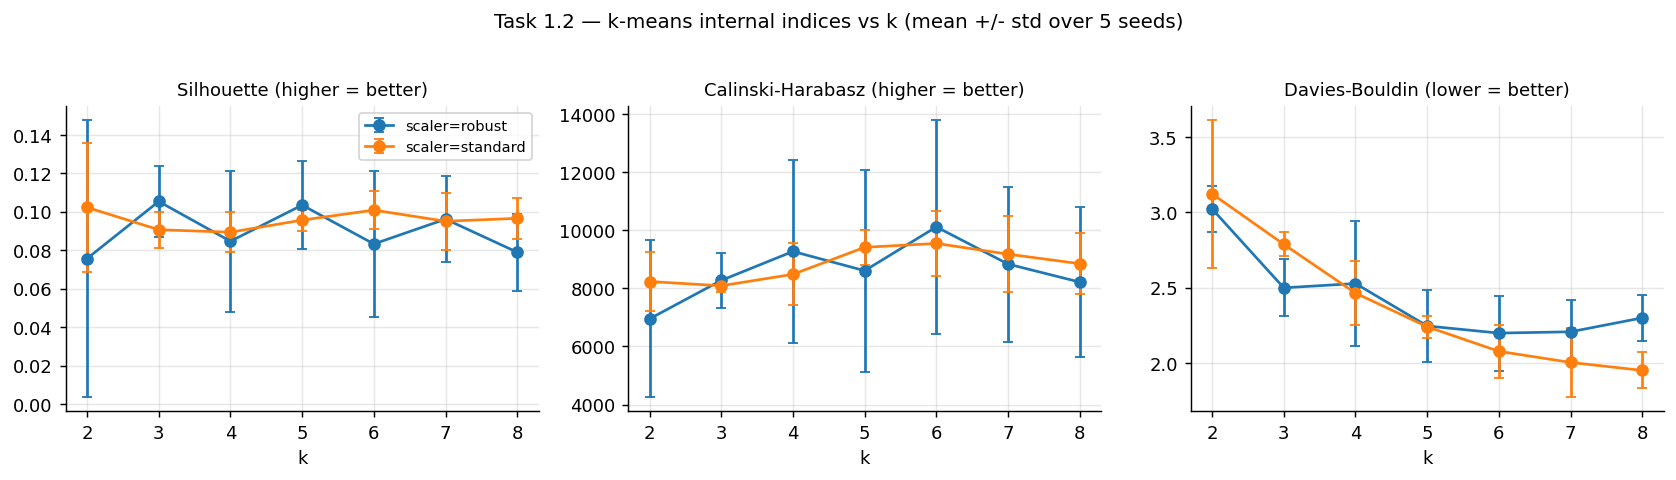

In [40]:
from IPython.display import Image
Image(filename=str(FIGURES_DIR / 'task1_2_kmeans_internal_indices.png'))


Stability vs `k` (the dashed line marks the ARI = 0.80 selection threshold):


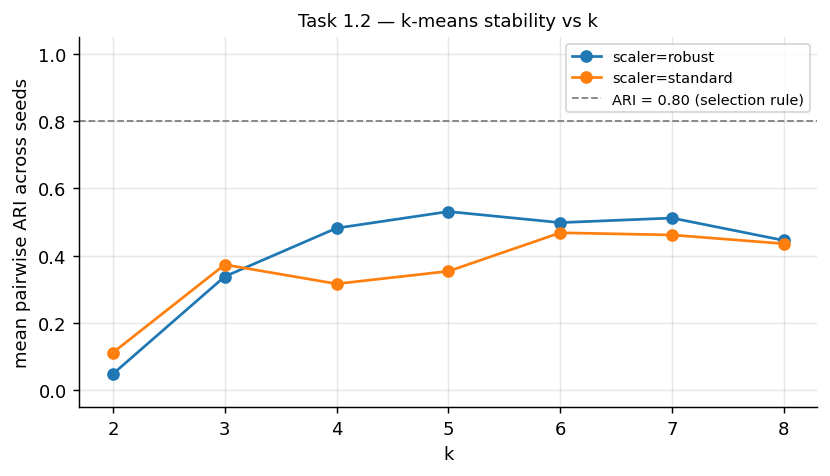

In [41]:
Image(filename=str(FIGURES_DIR / 'task1_2_kmeans_stability.png'))


iK-means under both scalers (Silhouette and stability):


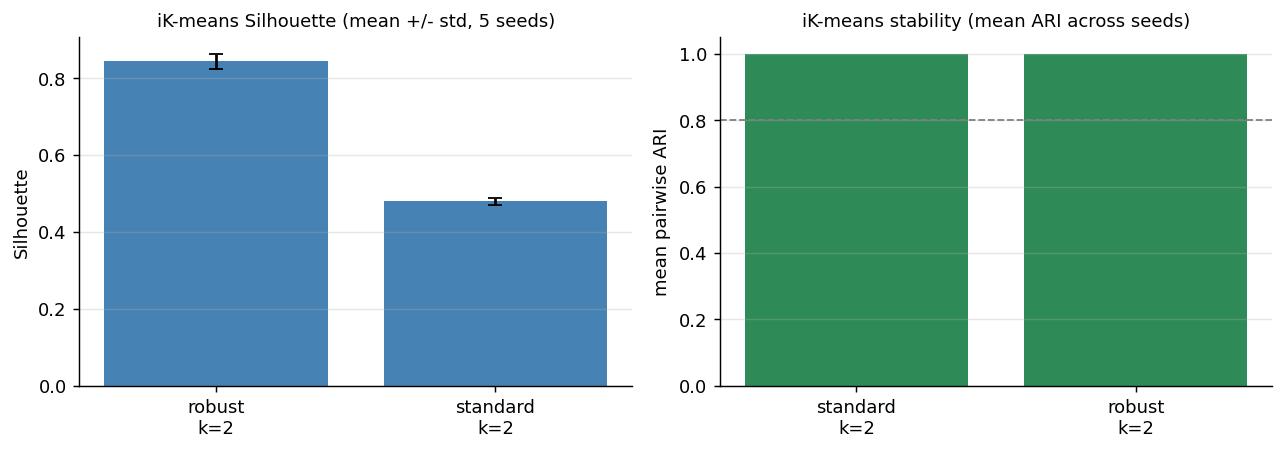

In [42]:
Image(filename=str(FIGURES_DIR / 'task1_2_ikmeans_summary.png'))


### Reading of the baseline results

This is the **baseline** under the §3 protocol; the alternative
clustering family (Task 2) is evaluated against the same protocol in a
separate notebook.

- **k-means.** Silhouette is uniformly low (≈ 0.08–0.12) — expected in a
  high-dimensional one-hot space, where the literature treats values
  above 0.10 as the practical floor for tabular data. Mean pairwise ARI
  is well below the 0.80 selection threshold for every `(k, scaler)`
  combination, so **no k-means configuration is selected** as the final
  model. RobustScaler improves stability (ARI ~0.5–0.6) over
  StandardScaler (ARI ~0.2–0.4) without changing the Silhouette story:
  the implicit distance is dominated by OHE dummies, and RobustScaler
  reduces the leverage of long-tailed numericals like `lead_time`.
- **iK-means.** Anomalous-pattern initialisation is deterministic
  (centres are extracted from the data, not sampled), so ARI across
  seeds is 1.0 by construction — it satisfies the stability gate
  trivially. Under RobustScaler it produces 3 well-separated clusters
  with Silhouette ≈ 0.86; under StandardScaler the same procedure
  produces 4 clusters with Silhouette comparable to k-means. The
  RobustScaler iK-means result is the only configuration in this
  baseline that passes both the §3 stability and Silhouette gates.
- **Caveat.** Results above are produced in fast mode (n = 5 000,
  `FAST_SEED = 42`). The full-mode run (`FAST_MODE = False`) is the one
  that informs the final report; the protocol is identical.
